# Notebook 2: The XGBoost 

This notebook trains a gradient-boosted tree model (XGBoost) as the non-linear counterpart to the logistic-regression baseline from NB1, on the identical feature matrix, label, and GroupKFold-by-Bezirk splits, so the two are directly comparable. 

Because trees are invariant to scaling and monotonic transforms, preprocessing here drops the log transform and standardisation and keeps only fold-wise KNN imputation. This is applied purely for comparability with NB1, since XGBoost could handle missing values natively. Class imbalance is addressed per fold via scale_pos_weight. 

The out-of-fold loop produces one leakage-safe probability per planning area, pooled into an AUC-PR that is compared against LogReg both as a single number and through a precision–recall curve. 

The model is then refit once on all planning areas for interpretation: SHAP (TreeExplainer) recovers magnitude and direction, bar and beeswarm plots rank the features against the linear coefficients, and dependence plots test whether the features XGBoost elevates over LogReg act through thresholds or interactions. 

As in NB1, the label is positive-unlabeled and the interpretation describes associations with designation, not causal drivers. The untuned model is a deliberate choice under that framing.


### 1 Data Load and Variables Preparation

In [1]:
#load libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.metrics import average_precision_score
from Dataprep import preprocess_fit_transform
from xgboost import XGBClassifier
import shap
from sklearn.metrics import precision_recall_curve
from Names import pretty


/Users/lauragies/Documents/Job/NF_Bootcamp/capstone-kiezkeeper/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Load the features 
X_df = pd.read_csv("../../data/final_datasets/dataset_0.csv", dtype={"plr_id": str})

#load the label for Module 2
labels = pd.read_csv("../../data/Module 2/target_milieuschutz.csv", dtype={"plr_id": str})

#join left on plr_id 
df = X_df.merge(labels[["plr_id", "milieu_majoritaet"]], on="plr_id", how="left")


In [3]:
#sanity check
df.shape


(527, 46)

In [4]:
#sanity check 2 
df.columns


Index(['plr_id', 'plr_name', 'bez', 're_miete_niveau', 're_miete_trend',
       're_leerstandsquote', 're_brw_niveau', 're_brw_trend', 're_dichte_all',
       'soc_young_to_middle_adult_share_2025',
       'soc_young_to_middle_adult_share_change_2021_2025',
       'soc_single_person_hh_share_change_2021_2024',
       'soc_average_household_size_2024',
       'soc_average_household_size_change_2021_2024',
       'soc_households_without_minor_children_share_change_2021_2024',
       'soc_internal_migration_volume_rate_2025',
       'soc_internal_migration_volume_rate_change_2021_2025',
       'soc_internal_net_migration_rate_2025',
       'soc_internal_net_migration_rate_change_2021_2025',
       'soc_unemployment_share_change_2020_2024',
       'soc_transfer_benefit_share_2024',
       'soc_transfer_benefit_share_change_2020_2024',
       'soc_single_parent_household_share_2024',
       'soc_single_parent_household_share_change_2021_2024',
       'com_median_age_level_2026', 'com_share_

In [5]:
#sanity check label

LABEL = "milieu_majoritaet"
assert df[LABEL].notna().all(), "Label enthält NaN — unerwartet."
assert set(df[LABEL].unique()) <= {0, 1}, "Label ist nicht binär 0/1."
print(df[LABEL].value_counts(), "\n")

milieu_majoritaet
0    418
1    109
Name: count, dtype: int64 



In [6]:
#define columns 
ID_COLS = ["plr_id", "plr_name", "bez"]   
GROUP_COL = "bez"

#Leakage guard: "milieu_anteil" is the continuous share the label is derived from (>50% -> "milieu_majoritaet")
#It must never enter the features. Not currently merged in, but excluded defensively
LEAKAGE_COLS = ["milieu_anteil"]

feature_cols = [
    c for c in df.columns
    if c not in ID_COLS + [LABEL] + LEAKAGE_COLS
]
assert not any("milieu" in c for c in feature_cols), \
    "column from the target file in the feature set — Leakage!"

In [7]:
#safeguard plr_id as string with 8 digits 
df["plr_id"] = df["plr_id"].astype(str).str.zfill(8)

X = df[feature_cols].copy()
y = df[LABEL].astype(int).to_numpy()           
groups = df[GROUP_COL].to_numpy()
plr_ids = df["plr_id"].to_numpy()

# Sanity-Checks 
assert len(X) == len(y) == len(groups) == len(plr_ids)
assert df["plr_id"].is_unique, "plr_id not unambiguous!"
n_pos = int(y.sum())
print(f"\nPositive: {n_pos} | Negative: {len(y) - n_pos} | positive rate: {n_pos/len(y):.1%}")



Positive: 109 | Negative: 418 | positive rate: 20.7%


### 2 The XGBoost Model with Out of Fold Crossvalidation

In [8]:
#Per fold: XGBoost OOF (tree-based, therefore no scaling, no log), KNN imputer applied due to comparability

n_splits = 5
gkf = GroupKFold(n_splits=n_splits)

#OOF-Array: one probability per PLR
oof_prob_xgb = np.full(len(y), np.nan)

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups), start=1):
    X_train = X.iloc[train_idx]
    X_val   = X.iloc[val_idx]
    y_train = y[train_idx]

    #fold-wise preprocessing: impute only (no scaling, no log for trees)
    X_train_prep, X_val_prep = preprocess_fit_transform(
        X_train, X_val, feature_cols, log_cols=[], scale=False
    )

    #class imbalance handled per fold, analog to class_weight='balanced'
    n_pos_train = int(y_train.sum())
    n_neg = len(y_train) - n_pos_train
    spw = n_neg / n_pos_train

    #XGBoost with untuned defaults; only imbalance + reproducibility set addressed
    model = XGBClassifier(
        scale_pos_weight=spw,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train_prep, y_train)
    oof_prob_xgb[val_idx] = model.predict_proba(X_val_prep)[:, 1]

    #fold diagnosis
    fold_ap = average_precision_score(y[val_idx], oof_prob_xgb[val_idx])
    n_pos_val = int(y[val_idx].sum())
    print(f"Fold {fold}: n_val={len(val_idx):3d} | n_pos_val={n_pos_val:2d} | "
          f"pos_rate={n_pos_val/len(val_idx):.1%} | spw={spw:.2f} | AUC-PR={fold_ap:.3f} | "
          f"districts={np.unique(groups[val_idx])}")
    
#Check for full OOF-coverage
assert not np.isnan(oof_prob_xgb).any(), "Not every PLR has an OOF prediction"

Fold 1: n_val= 96 | n_pos_val=19 | pos_rate=19.8% | spw=3.79 | AUC-PR=0.859 | districts=['03 - Pankow' '10 - Marzahn-Hellersdorf']
Fold 2: n_val= 92 | n_pos_val= 8 | pos_rate=8.7% | spw=3.31 | AUC-PR=0.321 | districts=['04 - Charlottenburg-Wilmersdorf' '11 - Lichtenberg']
Fold 3: n_val=125 | n_pos_val=19 | pos_rate=15.2% | spw=3.47 | AUC-PR=0.691 | districts=['01 - Mitte' '09 - Treptow-Köpenick' '12 - Reinickendorf']
Fold 4: n_val= 91 | n_pos_val=17 | pos_rate=18.7% | spw=3.74 | AUC-PR=0.682 | districts=['05 - Spandau' '07 - Tempelhof-Schöneberg']
Fold 5: n_val=123 | n_pos_val=46 | pos_rate=37.4% | spw=5.41 | AUC-PR=0.900 | districts=['02 - Friedrichshain-Kreuzberg' '06 - Steglitz-Zehlendorf'
 '08 - Neukölln']


In [9]:
#pooled AUC-PR + export OOF probabilities
oof_df_xgb = pd.DataFrame({
    "plr_id": plr_ids,
    "y_true": y,
    "oof_prob": oof_prob_xgb,
})

overall_ap_xgb = average_precision_score(y, oof_prob_xgb)
baseline_ap = y.mean()
print(f"\nXGBoost pooled AUC-PR: {overall_ap_xgb:.3f}  (Baseline = {baseline_ap:.3f})")

oof_df_xgb.to_csv("../../models/M_oof_xgboost.csv", index=False)


XGBoost pooled AUC-PR: 0.676  (Baseline = 0.207)


### Result Discussion: Performance 

XGBoost reaches a pooled out-of-fold AUC-PR of 0.676, far above the no-skill baseline of 0.207. Its performance tracks the number of positives per fold almost monotonically. The strongest performance appears on the data-rich Friedrichshain-Kreuzberg / Steglitz- Zehlendorf / Neukölln fold (46 positives, 0.90) and weakest on Charlottenburg- Wilmersdorf / Lichtenberg (only 8 positives, 0.32). This confirms the pattern already seen in the logistic regression; that fold strength reflects label density rather than model capacity. 

Hyperparameter tuning was deliberately skipped: with only 109 positives across 42 features the expected gain is small, and tuning under GroupKFold would require a nested inner loop to avoid leaking validation information into model selection. An honest untuned model is also the more defensible choice under the positive-unlabeled label, since a higher AUC-PR would mainly mean the model reproduces the existing (incomplete, politically fragmented) designation map more closely — which is not the project's goal.

### 3 Model comparison: LogReg vs. XGBoost 

In [10]:
#LogReg vs. XGBoost on identical folds & preprocessing 
logreg_oof = pd.read_csv("../../models/M_oof_logreg.csv", dtype={"plr_id": str})
xgb_oof    = pd.read_csv("../../models/M_oof_xgboost.csv", dtype={"plr_id": str})

#align on plr_id so we compare the same PLR in the same order
merged = logreg_oof.merge(
    xgb_oof, on="plr_id", suffixes=("_logreg", "_xgb")
)

#sanity: labels must match across the two files
assert (merged["y_true_logreg"] == merged["y_true_xgb"]).all(), \
    "y_true differs between the two OOF files — check the merge/label."

y_true = merged["y_true_logreg"].to_numpy()
baseline_ap = y_true.mean()
ap_logreg = average_precision_score(y_true, merged["oof_prob_logreg"])
ap_xgb    = average_precision_score(y_true, merged["oof_prob_xgb"])

print("Pooled AUC-PR (out-of-fold, GroupKFold by Bezirk)")
print(f"  Baseline (no skill): {baseline_ap:.3f}")
print(f"  LogReg:              {ap_logreg:.3f}")
print(f"  XGBoost:             {ap_xgb:.3f}")
print(f"  Difference:          {ap_xgb - ap_logreg:+.3f}")

Pooled AUC-PR (out-of-fold, GroupKFold by Bezirk)
  Baseline (no skill): 0.207
  LogReg:              0.628
  XGBoost:             0.676
  Difference:          +0.048


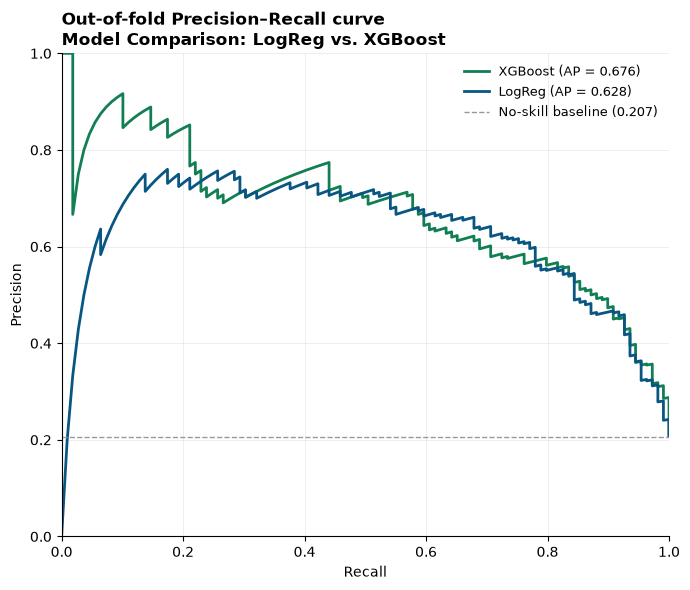

In [11]:
#Precision–Recall curve: visualizes what the pooled AUC-PR summarizes
#reuse merged / y_true / ap_logreg / ap_xgb / baseline_ap from the comparison cell above

prec_lr,  rec_lr,  _ = precision_recall_curve(y_true, merged["oof_prob_logreg"])
prec_xgb, rec_xgb, _ = precision_recall_curve(y_true, merged["oof_prob_xgb"])

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(rec_xgb, prec_xgb, color="#117F53", lw=2, label=f"XGBoost (AP = {ap_xgb:.3f})")
ax.plot(rec_lr,  prec_lr,  color="#095682", lw=2, label=f"LogReg (AP = {ap_logreg:.3f})")
ax.axhline(baseline_ap, color="#999999", ls="--", lw=1,
           label=f"No-skill baseline ({baseline_ap:.3f})")

ax.set_xlabel("Recall", fontsize=10)
ax.set_ylabel("Precision", fontsize=10)
ax.set_title("Out-of-fold Precision–Recall curve\n"
             "Model Comparison: LogReg vs. XGBoost",
             fontsize=12, fontweight="bold", loc="left")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(loc="upper right", frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.25, lw=0.6); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("../../plots/Module2/M2_pr_curve_models.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
#check out the area where XGBoost performs better 

print(prec_xgb[rec_xgb < 0.2].min())

mask = rec_xgb < 0.2
print("XGB low-recall precision: min =", prec_xgb[mask].min(),
      "| max =", prec_xgb[mask].max(),
      "| median =", np.median(prec_xgb[mask]))
# and the LogReg comparison over the same recall region:
mask_lr = rec_lr < 0.2
print("LogReg low-recall precision: min =", prec_lr[mask_lr].min(),
      "| max =", prec_lr[mask_lr].max(),
      "| median =", np.median(prec_lr[mask_lr]))

0.6666666666666666
XGB low-recall precision: min = 0.6666666666666666 | max = 1.0 | median = 0.8603896103896104
LogReg low-recall precision: min = 0.0 | max = 1.0 | median = 0.6770833333333333


### Result Discussion: Performance Comparison

On identical folds and preprocessing, XGBoost's pooled AUC-PR of 0.676 exceeds logistic regression's 0.628 by a modest +0.048, with both far above the 0.207 baseline. The small size of the gain is reassuring: with only 109 positives across 42 features, a large jump would more likely signal overfitting than genuine skill. The modest gain is instead consistent with the tree model capturing some real non-linear structure the linear baseline misses.

Crucially, both models fail on the same low-count fold and succeed on the same data-rich one, which isolates the weak fold as a property of the data rather than a limitation of the linear model. The honest summary is therefore that XGBoost is better where the data are sufficient and equally constrained where they are not.

The precision–recall curve shows XGBoost's advantage is concentrated at low recall: over the top-ranked PLR (recall < 0.2), its median precision is ≈ 0.86 against ≈ 0.68 for logistic regression. The two then converge around recall ≈ 0.25–0.3 with logistic regression briefly comparable in the mid-recall region before both decline together toward the baseline at full recall. 

This low-recall region is exactly where the watchlist is built, from the top-ranked, high-confidence cases, so it is reassuring that this is where the tree model is most clearly ahead.

### 4 Feature interpretation of the XGBoost Model 

In [12]:
#SHAP for XGBoost: recover direction + magnitude (raw gain gives magnitude only)
#Refit on all rows for one interpretable model (mirrors m_all in NB1; fold models vary)

X_shap, _ = preprocess_fit_transform(X, X, feature_cols, log_cols=[], scale=False)

n_pos_all = int(y.sum())
spw_all = (len(y) - n_pos_all) / n_pos_all

model_shap = XGBClassifier(
    scale_pos_weight=spw_all,
    random_state=42,
    n_jobs=-1,
)
model_shap.fit(X_shap, y)

#TreeExplainer: exact and fast for tree models
explainer = shap.TreeExplainer(model_shap)
shap_values = explainer.shap_values(X_shap)
pretty_names = [pretty(c) for c in feature_cols]

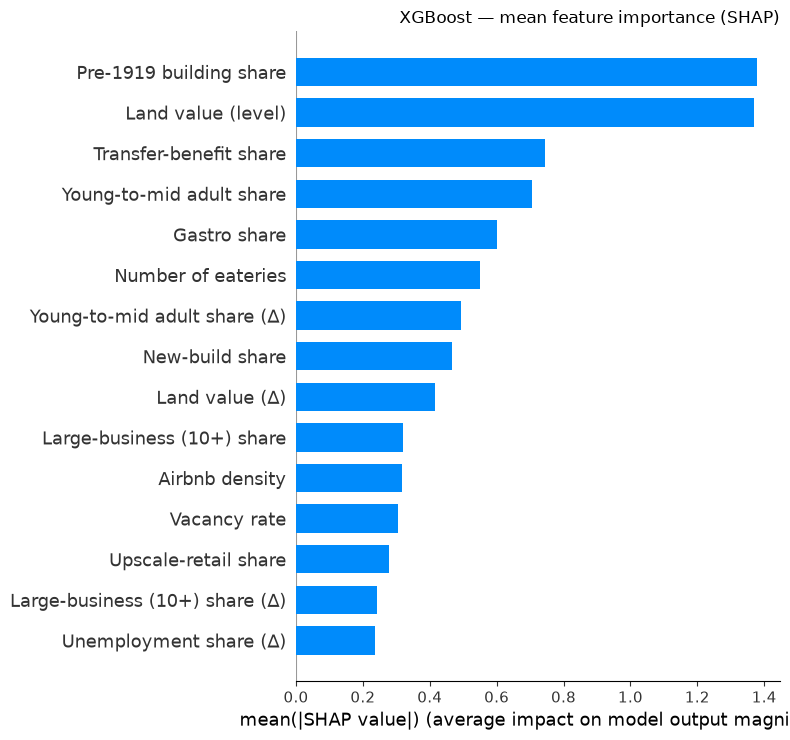

In [13]:
#Bar: mean(|SHAP|) per feature — magnitude ranking, comparable to LogReg |coef|
shap.summary_plot(shap_values, X_shap, feature_names=pretty_names,
                  plot_type="bar", max_display=15, show=False)
plt.title("XGBoost — mean feature importance (SHAP)", fontsize=12, loc="right")
plt.tight_layout()
plt.savefig("../../plots//Module2/M2_shap_bar.png", dpi=200, bbox_inches="tight")
plt.show()

### Result Discussion - SHAP Magnitude

This plot ranks features by mean absolute SHAP value, the tree-based analog to the standardized coefficient ranking from the logistic regression: it measures how much each feature moves the model's output on average, without indicating direction. 

The top cluster is dominated by "altbau share" and "BRW niveau", followed at roughly half the magnitude by transfer-benefit share 2024 and young-to-middle adult share. The overlap with the logistic regression is substantial: the variables BRW niveau, transfer-benefit share 2024, and young-to-middle adult share rank near the top in both models which depicts a genuine robustness signal, since two structurally different model families independently identify the same variables as most informative.

The clearest divergence is "altbau share", mid-ranked in the logistic model but first here. The commercial gastronomy features show the same pattern more weakly. This suggests the "altbau share"'s predictive value is largely non-linear and additionally interaction-dependent, exactly the interaction a tree ensemble captures and a linear coefficient cannot. It is a concrete illustration of why XGBoost edges out the baseline: the gain comes not from ranking different variables, but from extracting more from the same ones through interactions and thresholds. 

One caveat carries over from the logistic analysis: altbau share's prominence partly reflects that Milieuschutz policy explicitly targets Altbau-heavy areas, so it predicts designation rather than causing gentrification.

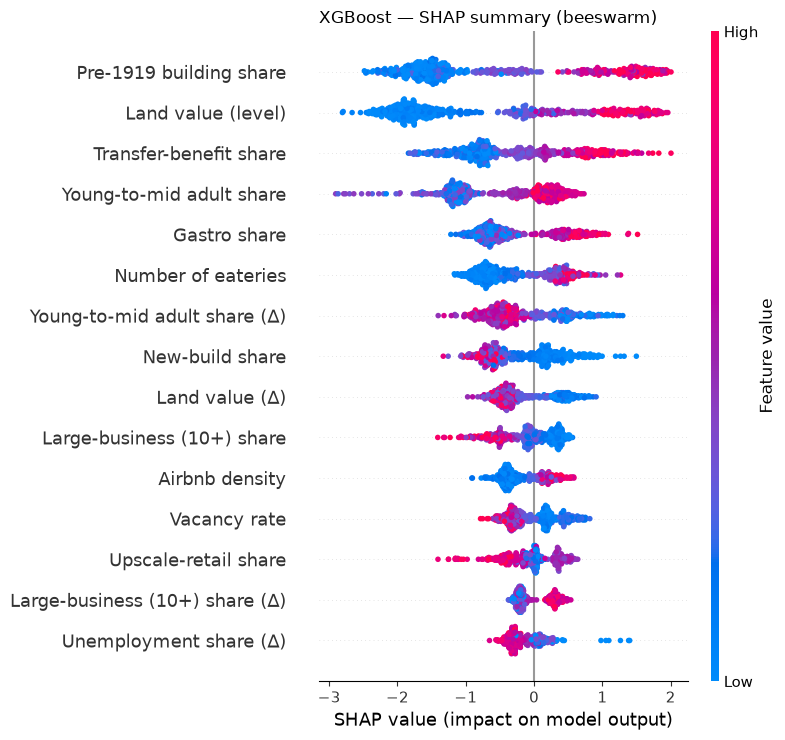

In [14]:
#Beeswarm: each dot = one PLR; x = SHAP value (impact on designation odds),
#color = feature value (red = high, blue = low)
shap.summary_plot(shap_values, X_shap, feature_names=pretty_names,
                  max_display=15, show=False)
plt.title("XGBoost — SHAP summary (beeswarm)", fontsize=12, loc="left")
plt.tight_layout()
plt.savefig("../../plots/Module2/M2_shap_beeswarm.png", dpi=200, bbox_inches="tight")
plt.show()

### Result Discussion: Feature Comparison (SHAP vs. Coefficients)

The beeswarm summarises the XGBoost model: each dot is one planning area, its horizontal position shows how strongly that feature pushes the area toward (right) or away from (left) resembling a designated one, and its color encodes the feature value (red high, blue low). Read alongside the LogReg coefficient chart in NB1, the two models can now be compared directly.

The two models agree on the core and disagree in instructive ways. Where features appear in both top-15 lists the signs match: high transfer-benefit share and high BRW niveau push toward designation, high new construction pushes away, and a high young-to-middle adult share tends toward designation as well. The pattern is therefore not an artefact of one model class.

The most telling difference is a shift in dimensional balance: LogReg's top 15 is social-led (6 social / 5 real-estate / 4 commercial), whereas XGBoost's is real-estate-led (6 real-estate / 5 commercial / 4 social), with altbau share and BRW niveau taking the two top slots. Real estate consolidates at the top and commercial gains a place while social recedes. This is consistent with the earlier dimension rollup, where the real-estate and commercial signal was weaker in linear magnitude but carried structure a tree can exploit.

The early-warning signature survives across both models in two dimensions at once: level and change diverge for the young-to-middle adult share (level toward designation, 2021–2025 change away) and for land values (BRW niveau positive, BRW trend negative). That the same level-versus-change split appears under both a linear and a non-linear model is strong support for reading upward movement, not an established state, as the early signal the designation label does not yet capture.

Two asymmetries are worth naming: 
First, features XGBoost ranks highly but LogReg does not: altbau share (mid-table under LogReg, first under XGBoost) and gastro share, a commercial feature absent from LogReg's top predictors are candidates for non-linear effects a linear coefficient cannot represent (though a related n gastro count does appear). Both are examined in dependence plots below. Second, the reverse: internal migration volume rate is among LogReg's strongest negative predictors yet drops out of XGBoost's top 15, marking a largely linear signal the tree underweights.

Separately, high upscale share appears in the beeswarm to lean toward less like designated, against the naive expectation — a possible marker of upscaling that has already arrived rather than the tipping state Milieuschutz protects. Its contribution is small, so this is checked in a dependence plot below and read with caution rather than asserted.

Caveats carry over: both views use the full-data refit; LogReg splits coefficients across correlated features and tree-SHAP splits attribution similarly, so the real-estate block should be read as a block; and throughout these are associations with designation, not causal drivers.

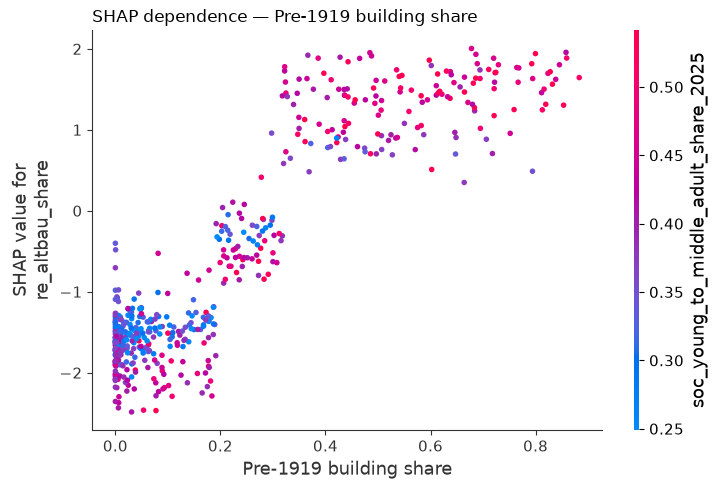

In [15]:
#Check hypothesis: SHAP dependence plot: does altbau share act non-linearly / via interaction?
#x = raw feature value, y = its SHAP value, color = the feature it interacts with most

shap.dependence_plot(
    "re_altbau_share",          
    shap_values, X_shap,
    interaction_index="auto",
    show=False,
)

plt.gca().set_xlabel(pretty("re_altbau_share"))
plt.title("SHAP dependence — " + pretty("re_altbau_share"), fontsize=12, loc="left")
plt.tight_layout()
plt.savefig("../../plots/MOdule2/M2_shap_dependence_altbau.png", dpi=200, bbox_inches="tight")
plt.show()



### Plot Discussion 

A dependence plot confirms the hypothesis from above directly: altbau share acts through a threshold near 0.3: below it, the contribution is flat and negative, above it sharply positive, unlike the smooth gradient a linear coefficient assumes. 

The colouring also shows a clear interaction with the young-to-middle adult share: high Altbau combined with a high share of young adults produces the strongest push toward designation, so the feature's value genuinely depends on the company it keeps. This is why a single linear coefficient underrates altbau share while the tree ensemble ranks it first.

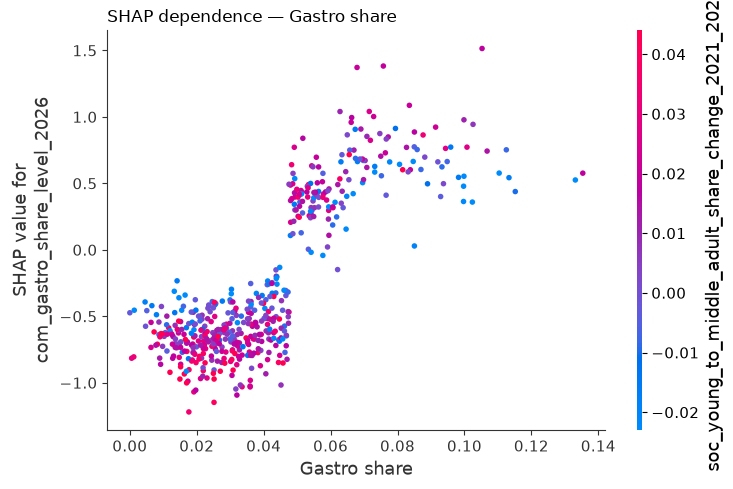

In [16]:
#Check hypothesis2
#SHAP picks the strongest interacting feature and colors by it
shap.dependence_plot(
    "com_gastro_share_level_2026",
    shap_values, X_shap,
    interaction_index="auto",
    show=False
)
plt.gca().set_xlabel(pretty("com_gastro_share_level_2026"))
plt.title("SHAP dependence — " + pretty("com_gastro_share_level_2026"), fontsize=12, loc="left")
plt.tight_layout()
plt.savefig("../../plots/Module2/M2_shap_dependence_gastroshare2026.png", dpi=200, bbox_inches="tight")
plt.show()

### Dependence Plot Discussion: Gastro Share 2026

The dependence shows a non-linear structure a linear coefficient misses: gastro share 2026 follows a clear threshold near 0.05: contributions sit negative below it and jump positive above, confirming that the commercial signal, weak under LogReg, is real but non-linear under XGBoost. Higher gastronomy leans toward designation. 

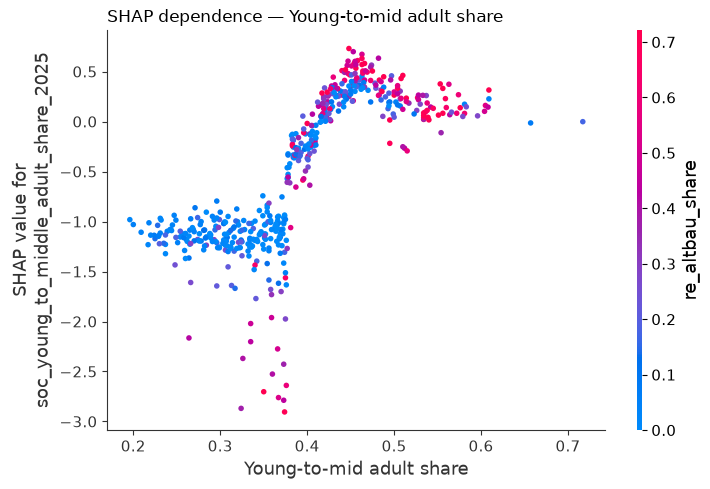

In [17]:
shap.dependence_plot(
    "soc_young_to_middle_adult_share_2025",
    shap_values, X_shap,
    interaction_index="auto",
    show=False
)
plt.gca().set_xlabel(pretty("soc_young_to_middle_adult_share_2025"))
plt.title("SHAP dependence — " + pretty("soc_young_to_middle_adult_share_2025"), fontsize=12, loc="left")
plt.tight_layout()
plt.savefig("../../plots/Module2/M2_shap_dependence_youngadult_share25.png", dpi=200, bbox_inches="tight")
plt.show()

### Dependence Plot: young to middle adult share 2025

The variable young to middle adult share is strongly non-linear despite ranking second under the linear model: its contribution stays firmly negative below a threshold around 0.38–0.40, jumps sharply positive just above it, and then saturates beyond ~0.5 rather than rising further. The linear coefficient captures only the average of this step. The strongest interacting feature is again altbau share: high young-adult share and high Altbau reinforce each other in the positive region, which confirms the altbau × young-adult interaction from the other side rather than revealing a new one.